In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from tqdm import tqdm
from sklearn.cluster import KMeans

In [2]:
rfm = pd.read_csv(r"D:\Machine_Learning_CDAC-AI\a] Datasets\rfm_data_customer.csv", index_col=0)
rfm

,revenue,most_recent_visit,number_of_orders,recency_days
customer_id,,,,
22086,777,2006-05-14,9,232
2290,1555,2006-09-08,16,115
26377,336,2006-11-19,5,43
24650,1189,2006-10-29,12,64
12883,1229,2006-12-09,12,23
...,...,...,...,...
3249,998,2006-12-01,10,31
6686,771,2006-06-28,8,187
16418,1016,2006-07-31,9,154


In [3]:
rfm = rfm.drop('most_recent_visit', axis=1)

In [4]:
scaler = StandardScaler().set_output(transform='pandas')
df_scaled = scaler.fit_transform(rfm)
Ks = [2,3,4,5]
scores= []
for i in Ks:
    clust = KMeans(n_clusters=i, random_state=26)
    clust.fit(df_scaled)
    scores.append([i, silhouette_score(df_scaled, clust.labels_)])

df_scores = pd.DataFrame(scores, columns=['clusters', 'scores'])
df_scores.sort_values('scores', ascending=False)

,clusters,scores
1,3,0.370431
0,2,0.361962
3,5,0.325342
2,4,0.322671


## Cluster Analysis

In [5]:
km = KMeans(n_clusters=3, random_state=26)
km.fit(df_scaled)
df = rfm.copy() 
df['Cluster'] = km.labels_
df.groupby('Cluster').mean()

,revenue,number_of_orders,recency_days
Cluster,,,
0,1285.523074,12.946774,133.283215
1,691.357762,7.343554,414.954233
2,753.347135,8.265399,135.530745


In [6]:
# Applying PCA for dimensionality reduction (for 2D visualization)

prcomp = PCA(n_components=2).set_output(transform='pandas')
pca_data = prcomp.fit_transform(df_scaled)

In [7]:
# Attach the cluster labels to the PCA dataframe

pca_data['cluster'] = km.labels_
pca_data['cluster'] = pca_data['cluster'].astype(str)

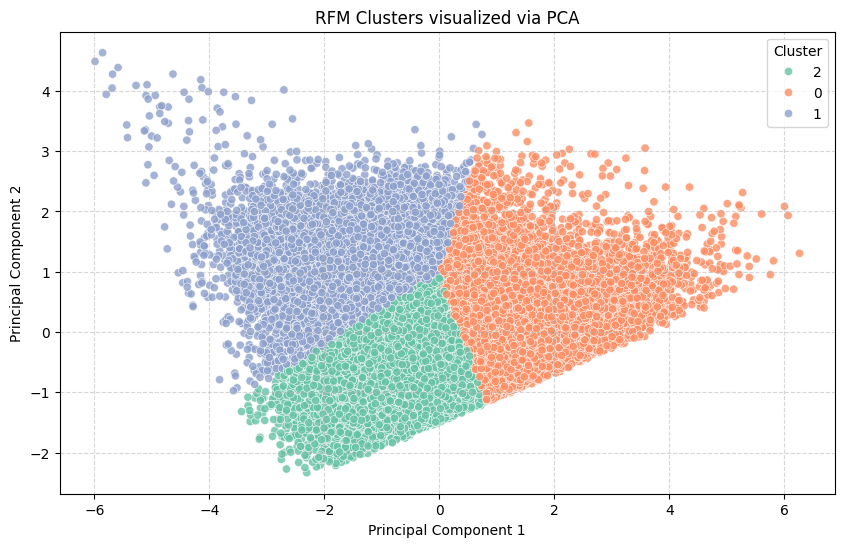

In [8]:
# Visualize the clusters in 2D Space

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca0',  # If using older sklearn, this might be 'pca_0'
    y='pca1',  # If using older sklearn, this might be 'pca_1'
    hue='cluster', 
    data=pca_data, 
    palette='Set2', 
    alpha=0.8
)
plt.title('RFM Clusters visualized via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)  # Everything goes nicely inside here!
plt.show()